# `Материалы кафедры ММП факультета ВМК МГУ. Практикум на ЭВМ`

# `Занятие 04. OpenCV и обработка изображений`

## `Занятие провел: Оганов Александр (tg: @welmud)`

## `Материалы составили: Денисов Егор (denisov.official72@gmail.com), Оганов Александр (tg: @welmud)`

### `Москва, Осенний семестр 2026`

Источники:

- [Сергей Михайлович Прокудин-Горский](https://ru.wikipedia.org/w/index.php?title=%D0%9F%D1%80%D0%BE%D0%BA%D1%83%D0%B4%D0%B8%D0%BD-%D0%93%D0%BE%D1%80%D1%81%D0%BA%D0%B8%D0%B9,_%D0%A1%D0%B5%D1%80%D0%B3%D0%B5%D0%B9_%D0%9C%D0%B8%D1%85%D0%B0%D0%B9%D0%BB%D0%BE%D0%B2%D0%B8%D1%87)

- [HSL/HSV](https://en.wikipedia.org/wiki/HSL_and_HSV)

- [Блог-пост OpenCV про цветовые пространства](https://opencv.org/color-spaces-in-opencv/)

- [Сайт демонстрации работы фильтров](https://setosa.io/ev/image-kernels/)

- [Фильтрация изображений с помощью фильтров](https://www.giassa.net/?page_id=635)

- [Фильтр Собеля](https://ru.wikipedia.org/wiki/%D0%9E%D0%BF%D0%B5%D1%80%D0%B0%D1%82%D0%BE%D1%80_%D0%A1%D0%BE%D0%B1%D0%B5%D0%BB%D1%8F)

- [Сайт с демонстрацией SVD для изображений](https://timbaumann.info/svd-image-compression-demo/)

- [Преобразование Фурье из документации OpenCV](https://docs.opencv.org/4.13.0/de/dbc/tutorial_py_fourier_transform.html)

- [CIFAR10](https://cave.cs.toronto.edu/kriz/cifar.html)

- [Torralba, Isola, & Freeman, Foundations of Computer Vision](https://visionbook.mit.edu/)

- [Пирамиды изображений из документации OpenCV](https://docs.opencv.org/4.13.0/dc/dff/tutorial_py_pyramids.html)

- [Jebamalar Leavline & Sutha, 2014](https://www.researchgate.net/publication/275038450_Design_of_FIR_Filters_for_Fast_Multiscale_Directional_Filter_Banks)

- [Keyu Tian et al., 2024](https://arxiv.org/pdf/2404.02905), примерно 1200 цитирований

- [Jia-Bin Huang, Видео с примерами смещивания изображений](https://youtu.be/U7qa7i0K9C4?si=Bea2-WRYfhTSVuuZ)

- [Морфологические операции](https://scikit-image.org/docs/0.20.x/auto_examples/segmentation/plot_morphsnakes.html)

- Ноутбук в основном основан на [ноутбуке 2023 года](https://github.com/mmp-practicum-team/mmp_practicum_fall_2023/blob/master/Seminars/04-image-processing-and-KNN/Seminar_4_cv_msu.ipynb)

- Часть материалов взята из [ноутбука 2022 года](https://github.com/mmp-practicum-team/mmp_practicum_fall_2022/blob/main/Seminars/04-image-processing-and-KNN/ImagesPython.ipynb)

---

In [1]:
import cv2 as cv
import skimage.io
import skimage.color
import skimage.transform
import scipy.ndimage
import PIL
from PIL import Image

import os
import random
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
SEED = 317
np.random.seed(SEED)
random.seed(SEED)

Наша первая цель познакомиться с обработкой изображений на Python. Для этого мы воспользуемся цветным изображением 1907 года, автором которого является Сергей Михайлович Прокудин-Горский. 

Подробнее про галерею и технологию получения цветных изображений можно почитать в источнике.

[Источник](https://ru.wikipedia.org/w/index.php?title=%D0%9F%D1%80%D0%BE%D0%BA%D1%83%D0%B4%D0%B8%D0%BD-%D0%93%D0%BE%D1%80%D1%81%D0%BA%D0%B8%D0%B9,_%D0%A1%D0%B5%D1%80%D0%B3%D0%B5%D0%B9_%D0%9C%D0%B8%D1%85%D0%B0%D0%B9%D0%BB%D0%BE%D0%B2%D0%B8%D1%87&oldid=155205984)

In [3]:
if not os.path.exists("emir.jpg"):
    !wget https://thumb.wikimedia.org/wikipedia/commons/thumb/3/33/Prokudin-Gorskii-19.jpg/960px-Prokudin-Gorskii-19.jpg
    !mv 960px-Prokudin-Gorskii-19.jpg emir.jpg

## Загрузка изображений

Для загрузки изображений мы можем использовать библиотеку PIL.

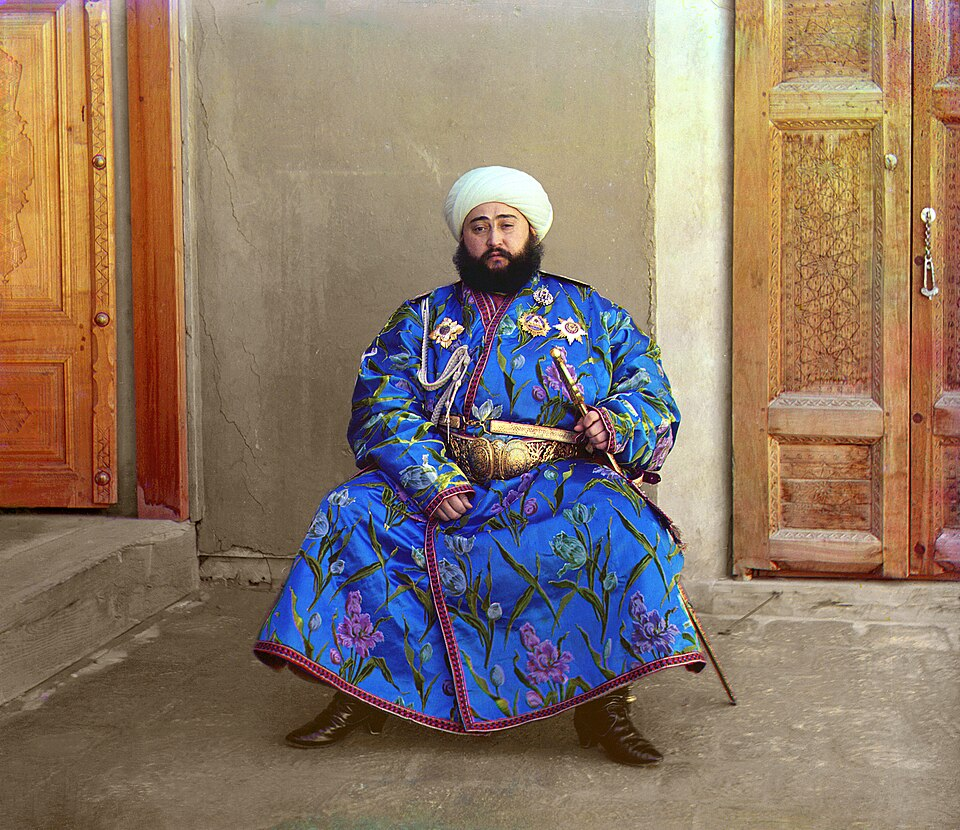

In [4]:
emir_image = PIL.Image.open('emir.jpg')
emir_image

Мы можем сразу посмотреть на свойства изображения.

In [5]:
type(emir_image), emir_image.format, emir_image.size, emir_image.mode

(PIL.JpegImagePlugin.JpegImageFile, 'JPEG', (960, 830), 'RGB')

Очень часто, нам удобно работать с изображением как с numpy массивом (тензором), для этого достаточно передать изображение в `np.array`.

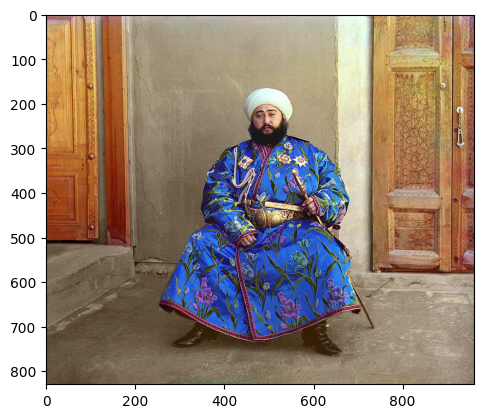

In [6]:
emir_array = np.array(emir_image)
plt.imshow(emir_array)
plt.show()

Также можно сразу получить изображение в виде тензора используя библиотеки matplotlib или skimage.

In [7]:
skimage_array = skimage.io.imread('emir.jpg')
np.testing.assert_almost_equal(emir_array, skimage_array)

plt_array = plt.imread('emir.jpg')
np.testing.assert_almost_equal(emir_array, plt_array)

Каждое цветное изображение &ndash; трехканальный тензор.

In [8]:
emir_array.shape # HxWxC

(830, 960, 3)

## Трансформации изображений

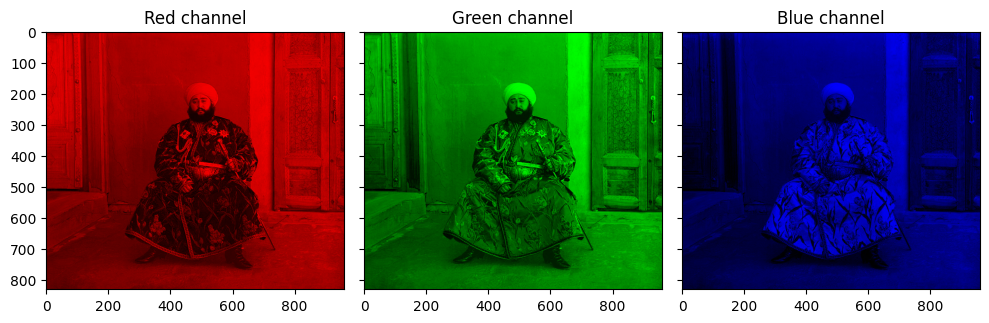

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(10, 4), sharex=True, sharey=True)

titles = ['Red channel', 'Green channel', 'Blue channel']
for i in range(3):
    zeros = np.zeros_like(emir_array)
    zeros[:, :, i] = emir_array[:, :, i]
    ax[i].imshow(zeros)
    ax[i].set_title(titles[i])

plt.tight_layout()
plt.show()

Изображения необязательно могут быть цветными, также они могут быть бинарными или в серых тонах

Формула для получения изображения в серых тонах:

$$ Y = 0.299R + 0.587G + 0.114B, $$
где $R$, $G$, $B$ отвечают за канал соотвествующего цвета.

Посмотрим как библиотечные функции переводят изображение в серые тона и бинаризуют.

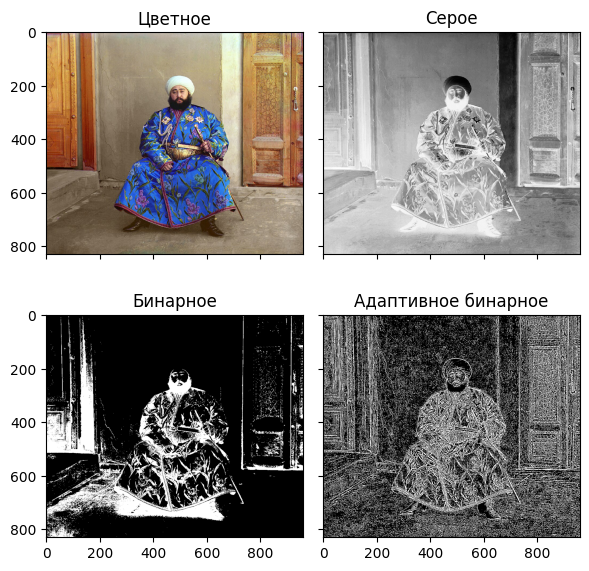

In [10]:
fig, ax = plt.subplots(2, 2, figsize=(6, 6), sharex=True, sharey=True)
ax = ax.ravel()

ax[0].set_title('Цветное')
ax[0].imshow(emir_array)

gray_image = cv.cvtColor(emir_array, cv.COLOR_BGR2GRAY)
ax[1].set_title('Серое')
ax[1].imshow(gray_image, cmap=plt.cm.Greys)


thresh, bin_image = cv.threshold(gray_image, 75, 75, cv.THRESH_BINARY)
ax[2].set_title('Бинарное')
ax[2].imshow(bin_image, cmap=plt.cm.Greys)


adaptive_bin_image = cv.adaptiveThreshold(gray_image, 255, cv.ADAPTIVE_THRESH_MEAN_C, 
                                         cv.THRESH_BINARY, 5, 5)
ax[3].set_title('Адаптивное бинарное')
ax[3].imshow(adaptive_bin_image, cmap=plt.cm.Greys)

plt.tight_layout()
plt.show()

Бинаризация бывает:

*   Глобальная (один порог для всех пикселей на фото);
*   Локальная (порог зависит от положения пикселя);
*   Адаптивная (порог зависит от положения и от яркости пикселя).



### HSV представление

Иногда бывает удобно работать не в RGB, а в иных представлениях, например, HSV.

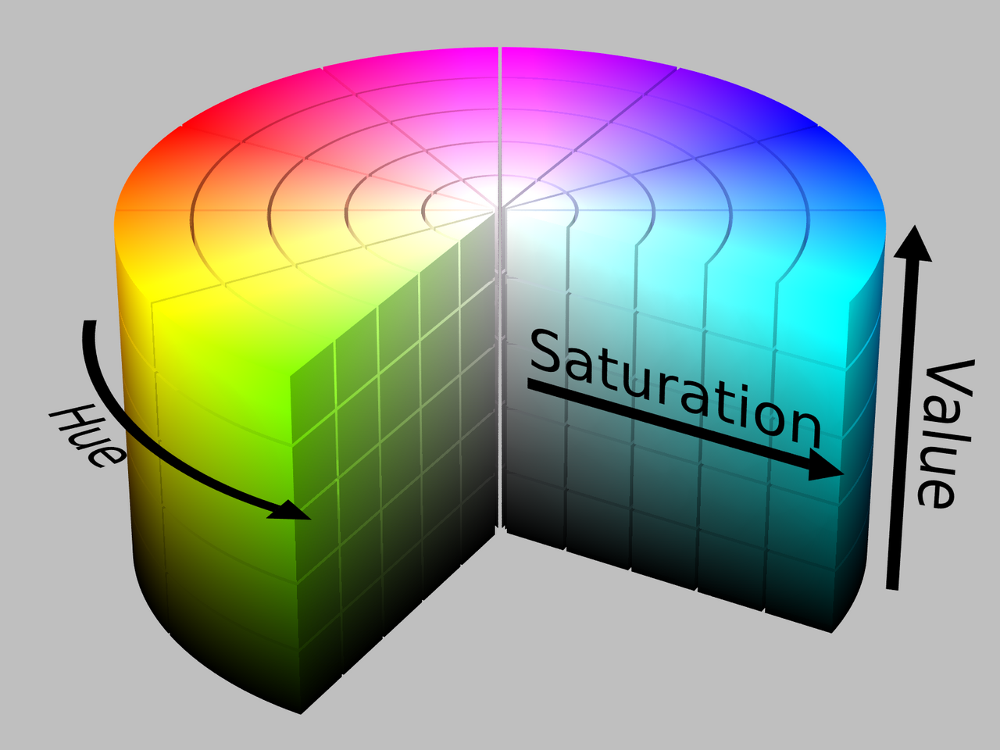

[Источник](https://en.wikipedia.org/wiki/HSL_and_HSV)

* Hue &ndash; цветовой тон, например, красный, зелёный или синий. Диапазон OpenCV от 0 до 180;

* Saturation &ndash; насыщенность. Чем больше этот параметр, тем "чище" цвет, поэтому этот параметр иногда называют чистотой цвета. Диапазон OpenCV от 0 до 255;

* Value &ndash; значение цвета, или Brightness &ndash; яркость. Диапазон OpenCV от 0 до 255.

HSV часто называют HSB пространством.

[Источник](https://opencv.org/color-spaces-in-opencv/)

In [11]:
emir_hsv = cv.cvtColor(emir_array, cv.COLOR_RGB2HSV)

emir_hsv.max(axis=(0,1))

array([179, 255, 255], dtype=uint8)

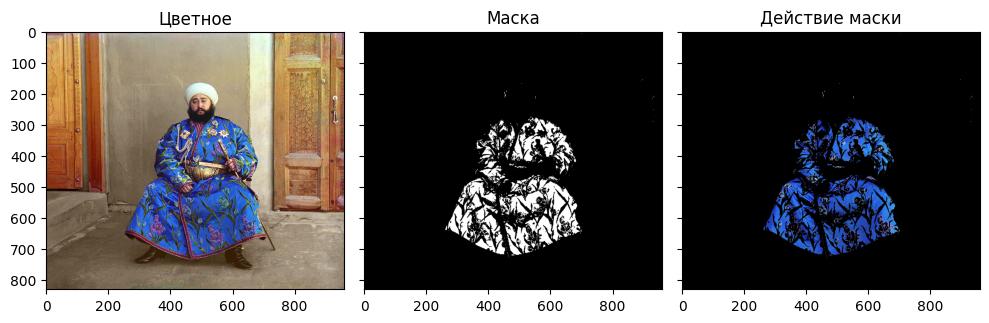

In [12]:
emir_hsv = cv.cvtColor(emir_array, cv.COLOR_RGB2HSV)

lower_blue = np.array([100, 0, 150])
upper_blue = np.array([130, 255, 255])
mask = cv.inRange(emir_hsv, lower_blue, upper_blue)

fig, ax = plt.subplots(1, 3, figsize=(10, 4), sharex=True, sharey=True)

ax[0].set_title("Цветное")
ax[0].imshow(emir_array)

ax[1].set_title("Маска")
ax[1].imshow(np.uint(mask), cmap='gray')


ax[2].set_title("Действие маски")
ax[2].imshow(emir_array * (np.uint(mask)[..., None] // 255), cmap='gray')

plt.tight_layout()
plt.show()

### Геометрические преобразования

Изображения можно поворачить, сдвигать и делать еще много разных интересных вещей...

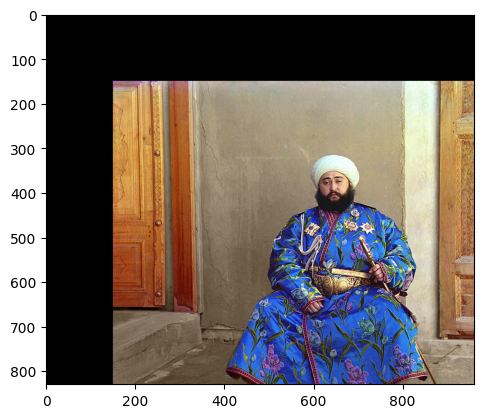

In [13]:
shifted_image = scipy.ndimage.shift(emir_array, [150, 150, 0])
plt.imshow(shifted_image)
plt.show()

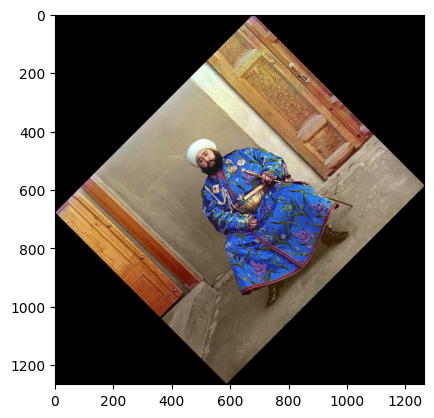

In [14]:
rotated_image = scipy.ndimage.rotate(emir_array, 45)
plt.imshow(rotated_image)
plt.show()

In [15]:
emir_array.shape, rotated_image.shape

((830, 960, 3), (1266, 1266, 3))

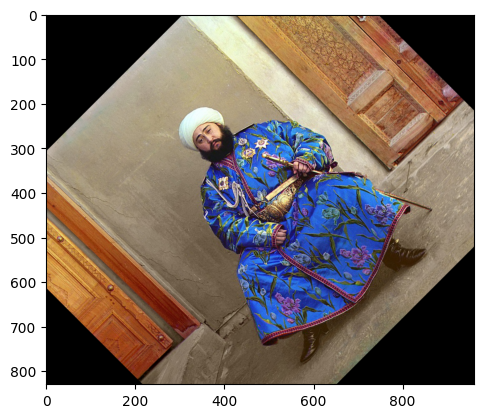

In [16]:
rotated_image = skimage.transform.rotate(emir_array, 45) # with resize=True equal to scipy.rotate 
plt.imshow(rotated_image)
plt.show()

In [17]:
emir_array.shape, rotated_image.shape

((830, 960, 3), (830, 960, 3))

Преобразования данных часто называют аугментацией. Например, для уменьшения переобучения алгоритмов машинного обучения мы можем увеличить выборку. На практике, получить новые размеченые данные не всегда возможно, поэтому мы можем попробовать как-то поработать с исходными данными. Например, в задачи классификации животных, мы можем чуть повернуть изображения или сдивинуть, так как от этого не поменяется класс объекта на изображении. Ниже мы сделали пример аугментации.

In [18]:
def very_smart_augmentation(image_array, a, b):
    angle = np.random.randint(-b, b, 1)[0]
    shift_x, shift_y = np.random.randint(-a, a, 2)
    img = scipy.ndimage.shift(image_array, [shift_y, shift_x, 0])
    img = skimage.transform.rotate(img, angle)
    return img

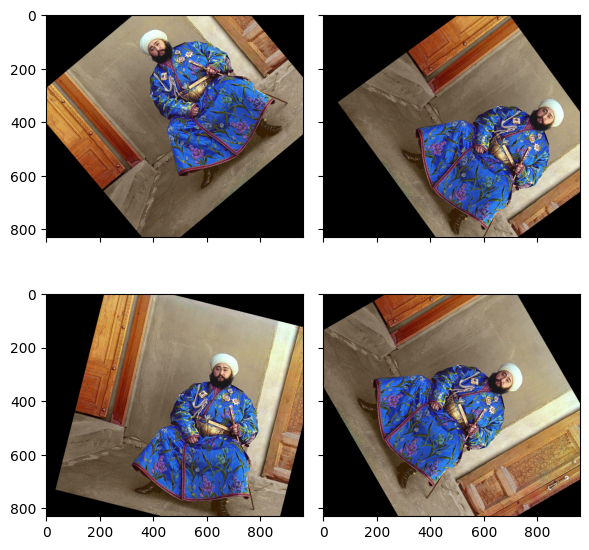

In [19]:
assert (very_smart_augmentation(emir_array, 200, 90) != emir_array).any(), "Maybe it's just chance 1e-1051251025105, but I think your code is wrong" 

a = 200
b = 90

fig, ax = plt.subplots(2, 2, figsize=(6, 6), sharex=True, sharey=True)
ax = ax.ravel()

for i in range(4):
    ax[i].imshow(very_smart_augmentation(emir_array, a, b))

plt.tight_layout()
plt.show()

### Фильтры

[Сайт c демонстрацией](http://setosa.io/ev/image-kernels/).

Фильтры &ndash; способ извлекать какие-либо признаки по фиксированному правилу из окрестности пикселей.

Например, мы можем для каждого пикселя рассмотреть его соседей, далее вытянуть соседей в вектор, найти медианну и вернуть медианну. Такой фильтр называется медианным, с его помощью можно удалять шумы с фото.

Более подробно про эту сущность вы узнаете в следующем семестре на курсе ОиРИ и ВвГО

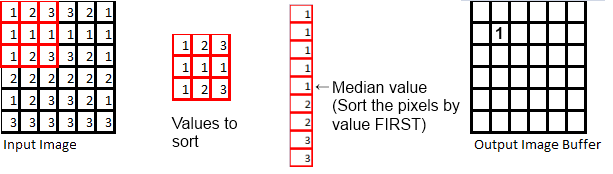

[Источник](https://www.giassa.net/?page_id=635)

In [20]:
if not os.path.exists('msu.jpg'):
    !wget https://turkmenportal.com/images/uploads/blogs/b1cec01f147f463a30d6ecb03fb74900.jpg
    !mv b1cec01f147f463a30d6ecb03fb74900.jpg msu.jpg

msu_array = skimage.io.imread('msu.jpg')
msu_gray = cv.cvtColor(msu_array, cv.COLOR_BGR2GRAY)

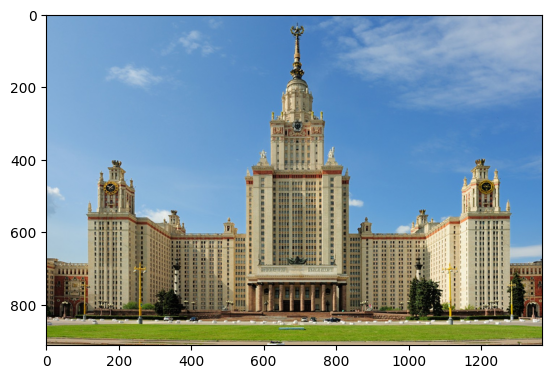

In [21]:
plt.imshow(msu_array)
plt.show()

Выберем какое-то количество пикселей и удалим их из изображения. После чего используем медианный фильтр (scipy.ndimage.median_filter), чтобы восстановить изображение любимого вуза.

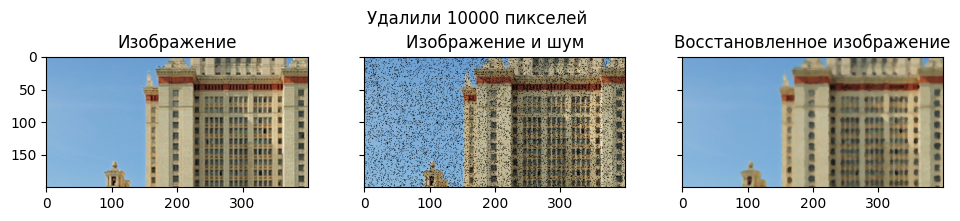

In [22]:
K = 10000

img_copy = msu_array[400:600, 400:800].copy()
noise_x = np.random.choice(img_copy.shape[1], size=K)
noise_y = np.random.choice(img_copy.shape[0], size=K)


fig, ax = plt.subplots(1, 3, figsize=(10, 2), sharex=True, sharey=True)

ax[0].imshow(img_copy)
ax[0].set_title("Изображение")

img_copy[noise_y, noise_x, :] = 0
ax[1].imshow(img_copy)
ax[1].set_title("Изображение и шум")


msu_filtered = cv.medianBlur(img_copy, 5)
ax[2].imshow(msu_filtered)
ax[2].set_title("Восстановленное изображение")

fig.suptitle(f"Удалили {K} пикселей")
plt.tight_layout()
plt.show()

Пример применения гауссовского фильтра, позволяющего размыть фото. В этом случае, мы действуем по каналам и возвращаем для каждого канала матрицу:


$$ Y[i, j] = \sum_{l = -k}^k \sum_{m = -k}^k X[i + l, j + m] \frac{1}{\sqrt{2 \pi \sigma}} \exp\left(-\frac{\sqrt{l^2 + m^2}}{2\sigma^2}\right).$$

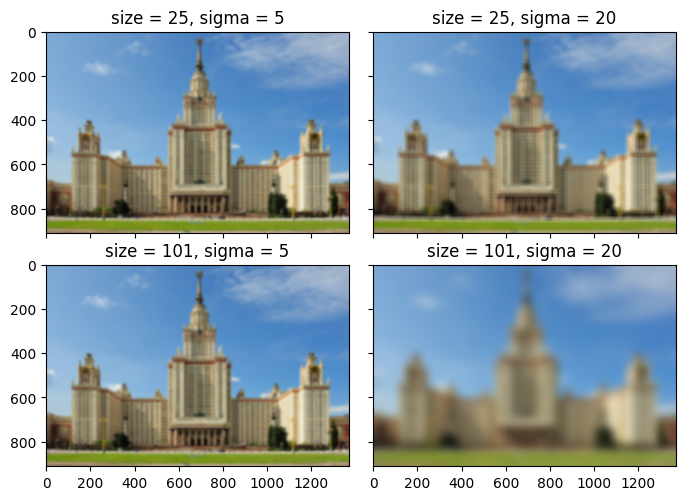

In [23]:
fig, ax = plt.subplots(2, 2, figsize=(7, 5), sharex=True, sharey=True)

for i, k in enumerate([25, 101]):
    for j, sigma in enumerate([5, 20]):
        blured_msu = cv.GaussianBlur(msu_array, (k, k), sigma)
        ax[i][j].imshow(blured_msu)
        ax[i][j].set_title(f"size = {k}, sigma = {sigma}")
        
plt.tight_layout()
plt.show()

C помощью фильтров мы можем выделять контуры изображения, например с помощью [фильтра Собеля](https://ru.wikipedia.org/wiki/%D0%9E%D0%BF%D0%B5%D1%80%D0%B0%D1%82%D0%BE%D1%80_%D0%A1%D0%BE%D0%B1%D0%B5%D0%BB%D1%8F).

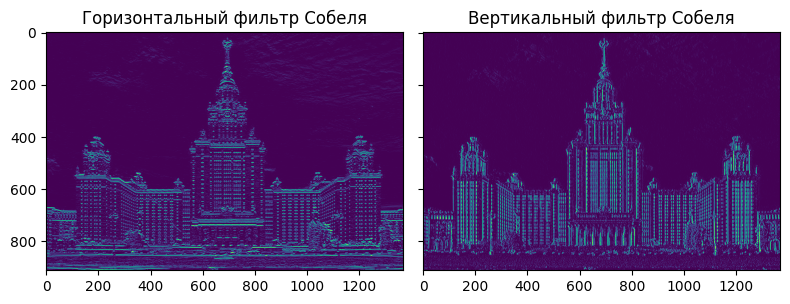

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(8, 5), sharex=True, sharey=True)

kernel = np.array([[1, 2, 1], 
                   [0, 0, 0],
                   [-1, -2, -1]])
msu_horizontal = cv.filter2D(msu_gray, 0, kernel)
ax[0].imshow(msu_horizontal)
ax[0].set_title("Горизонтальный фильтр Собеля")


kernel = np.array([[1, 0, -1], 
                   [2, 0, -2],
                   [1, 0, -1]])
msu_vertical = cv.filter2D(msu_gray, 0, kernel)
ax[1].imshow(msu_vertical)
ax[1].set_title("Вертикальный фильтр Собеля")

plt.tight_layout()
plt.show()

#### <font color='Orange'>**Вопрос:**</font>  Почему ядра фильтров выглядят именно так?

Ответ:

Это способ записать разностную производную по направлению, то есть мы визуализируем то, где произовдная большая, а значит мы найдем контур изображения.

####

## SVD

[Сайт c демонстрацией](http://timbaumann.info/svd-image-compression-demo/)

Пусть $A \in \mathbb{R}^{m \times n}$, тогда SVD разложение $A$ записывается в следующем виде:

\begin{align}
& A = U \Sigma V^{*}, \quad  U \in R^{m \times m}, ~ \Sigma \in R^{m \times n}, ~V \in R^{n \times n},\\
& UU^{*} = I_m, ~V^{*}V=I_n.
\end{align}


Альтернативная запись:
$$A = \sum_{i = 1}^{rank(A)}{\sigma_i u_i v_i^*}$$


#### <font color='Orange'>**Вопрос:**</font> Какие хорошие свойства SVD вы знаете?

Ответ:

С помощью SVD можно легко получать малоранговые приближения, сжимать или решить задачу линейной регрессии.

####

**Псевдообратная матрица**

$A^\dagger = V\Sigma^{-1} U^{*}$ или же...

$$ A^\dagger = \lim_{\lambda \to +0} (A^{*}A + \lambda I)^{-1}A^*.$$

Чем-то напоминает решение линейной регрессии...

Какой смысл у псевдообратный матрицы?

$Aw = y$, то $\hat{w} := A^\dagger y~$ соответсвует $argmin_{w} \| Aw - y\|_2$, причем если решений бесконечно много, то $\hat{w}$ имеет наименьшую норму.

[Псевдообратная матрица](https://ru.wikipedia.org/wiki/%D0%9F%D1%81%D0%B5%D0%B2%D0%B4%D0%BE%D0%BE%D0%B1%D1%80%D0%B0%D1%82%D0%BD%D0%B0%D1%8F_%D0%BC%D0%B0%D1%82%D1%80%D0%B8%D1%86%D0%B0)

**Малоранговое приближение**

Пусть $A \in \mathbb{R}^{m \times n}$, назовем $$A_k = U_k \Sigma_k V^{*}_k, ~ U_k = U[:, :k], ~ \Sigma_k = \Sigma[:k, :k], ~V_k = V[:k, :].$$

Из курса линейной алгебры известно:

$$ A_k = argmin_{B \in \mathbb{R}^{m \times n}, rank(B) = k} \|A - B \|_F.$$

Напоминим, что $\| A \|_F = \sqrt{\sum_{i,j} a_{ij}^2}$ или же равно корню из суммы квадратов сингулярных чисел.

In [25]:
def trunc_svd(A, k):
    U, S, Vh = np.linalg.svd(A, full_matrices=False)
    return U[:, :k + 1], S[:k + 1],  Vh[:k + 1]

Мы будем работать отдельно по каналам, так как для разложении тензоров придется применять более сложные методы.

In [26]:
c = 0

A = np.copy(msu_array)
A_c = A[:, :, c]
_, sing_vals, _ = np.linalg.svd(A_c)

Посмотрим как убывают сингулярные числа.

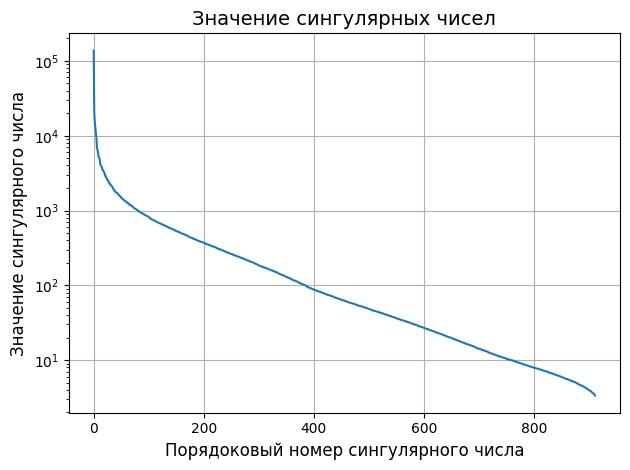

In [27]:
plt.title("Значение сингулярных чисел", fontsize=14)
plt.plot(sing_vals)
plt.grid()
plt.xlabel("Порядоковый номер сингулярного числа", fontsize=12)
plt.ylabel("Значение сингулярного числа", fontsize=12)
plt.yscale('log')

plt.tight_layout()
plt.show()

Оставим первые 20 сингулярных чисел, то есть будем искать наилучшее преближение среди матриц ранга 20.

In [28]:
k = 20

U, S, Vh = trunc_svd(A_c, k)
A_k = U @ np.diag(S) @ Vh

assert abs(np.linalg.norm(A_c - A_k) - np.linalg.norm(sing_vals[k + 1:])) < 1e-5

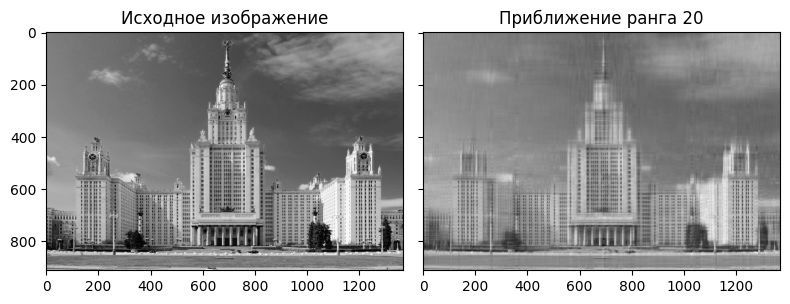

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(8, 5), sharex=True, sharey=True)

ax[0].imshow(A_c, cmap="gray")
ax[0].set_title("Исходное изображение")

ax[1].imshow(A_k, cmap="gray")
ax[1].set_title(f"Приближение ранга {k}")

plt.tight_layout()
plt.show()

Посмотрим какой ранг каждого из каналов.

In [30]:
for i in range(3):
    r = np.linalg.matrix_rank(A[:, :, i])
    print(f"rank(A[:, :, {i}]) = {r}")

rank(A[:, :, 0]) = 912
rank(A[:, :, 1]) = 912
rank(A[:, :, 2]) = 912


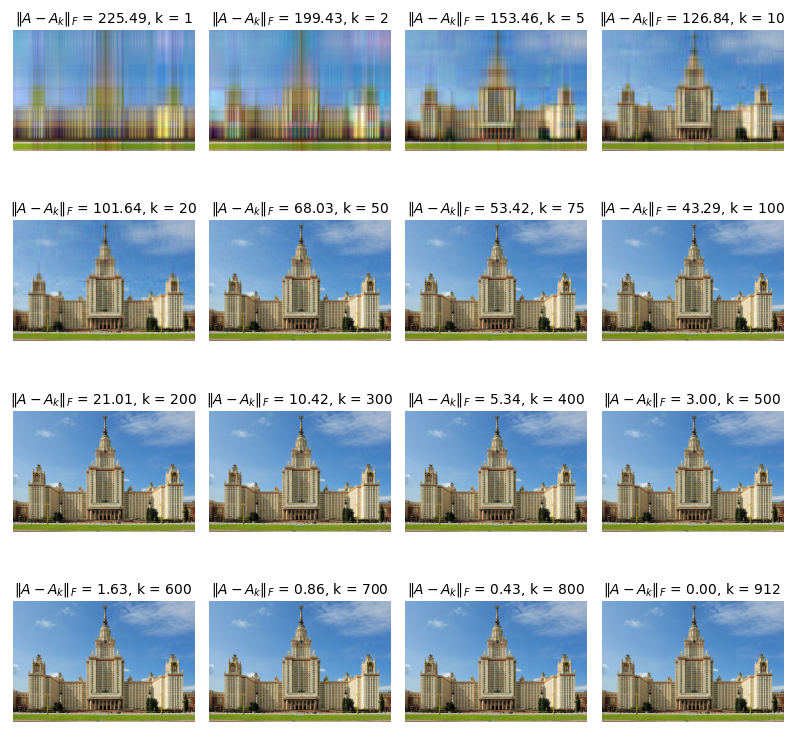

In [31]:
k_grid = [1, 2, 5, 10, 20, 50, 75, 100, 200, 300, 400, 500, 600, 700, 800, 912]
A = msu_array.copy() / 255

N = len(k_grid)
k = int(np.sqrt(N))
k = k if k * k == N else k + 1

base_size = 2
fig, ax = plt.subplots(k, k, figsize=(base_size * k, base_size * k), sharex=True, sharey=True)
ax = ax.ravel()

for idx, k in enumerate(k_grid):
    A_k = np.zeros_like(A)
    for i in range(3):
        U, S, Vh = trunc_svd(A[:, :, i], k)
        A_k[:, :, i] = U @ np.diag(S) @ Vh
        A_k = np.clip(A_k, 0, 1)
    
    ax[idx].axis('off')
    ax[idx].imshow(A_k)
    ax[idx].set_title(fr"$\|A - A_k \|_F$ = {np.linalg.norm(A - A_k):0.2f}, k = {k}", fontsize=10)
    
plt.tight_layout()
plt.show()  

## Преобразование Фурье

Мы можем смотреть на изображение как на функцию с дискретными аргументами, а значит можем применить дискретное преобразование Фурье.

Формулка дискретного двумерного преобразования Фурье:
$$F(u, v) = \frac{1}{MN} \sum_{x = 0}^{M - 1}{\sum_{y = 0}^{N - 1}{f(x, y)e^{-i2\pi(\frac{ux}{M} + \frac{vy}{N})}}}.$$


Далее мы посчитаем Фурье спектр для чёрно-белого изображения. Из курса анализа мы знаем, что одни коэффиценты Фурье соотвествуют низким частотам (крупные детали изображений), другие высоким (мелкие детали изображений).

[Пример из OpenCV](https://docs.opencv.org/4.x/de/dbc/tutorial_py_fourier_transform.html)

In [32]:
img = cv.imread('msu.jpg', cv.IMREAD_GRAYSCALE)

Посчитаем дискретное преобразование Фурье. Для визуализации рассмотрим магнитуды.

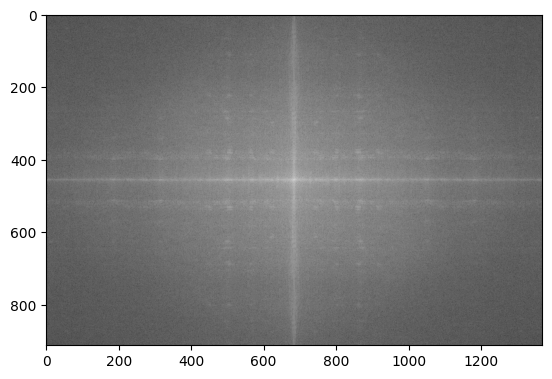

In [33]:
dft = cv.dft(np.float32(img), flags=cv.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)
magnitude = 20 * np.log(cv.magnitude(dft_shift[:,:,0], dft_shift[:,:,1]))

plt.imshow(magnitude, cmap='gray')
plt.show()

Рассмотрим частоты, которые соотвествуют частотам из центра, сторона квадрата будет $2k + 1$ (чем ближе к центру, тем ниже частота).

In [34]:
k = 7
rows, cols = img.shape
crow, ccol = rows // 2 , cols // 2

mask = np.zeros((rows, cols, 2), np.uint8)
mask[crow - k:crow + k + 1, ccol - k:ccol + k + 1] = 1
mask[crow - k:crow + k + 1, ccol - k:ccol + k + 1].shape

(15, 15, 2)

In [35]:
def inverse_fourier(dft_shift, mask):
    fshift = dft_shift * mask
    f_ishift = np.fft.ifftshift(fshift)
    img_back = cv.idft(f_ishift)
    img_back = cv.magnitude(img_back[:,:,0], img_back[:,:,1])
    
    return img_back

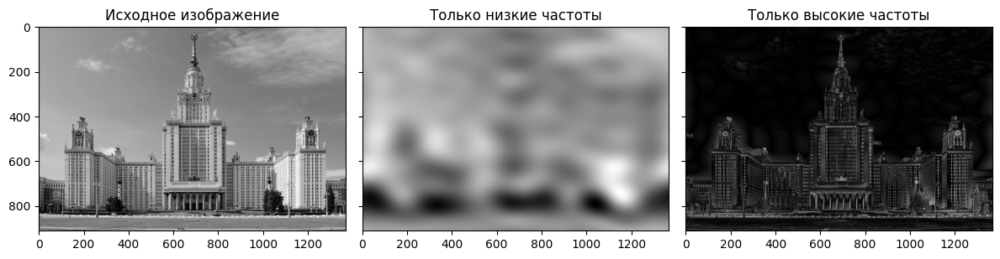

In [36]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)
ax[0].imshow(img, cmap = 'gray')
ax[0].set_title('Исходное изображение')

img_back = inverse_fourier(dft_shift, mask)

ax[1].imshow(img_back, cmap='gray')
ax[1].set_title('Только низкие частоты')


img_back = inverse_fourier(dft_shift, 1 - mask)

ax[2].imshow(img_back, cmap = 'gray')
ax[2].set_title('Только высокие частоты')

plt.tight_layout()
plt.show()

Из демонстрации видно, что низкие частоты соотвествуют башням (общая структура), а высокие контурам здания (детали).

Далее посмотрим, сколько низких частот достаточно оставить, чтобы изображение визуально не особо изменилось (при этом мы сократим размерность пространства).

In [37]:
def fft_transform(img, k, vis=False):
    font_size = 12
    rows, cols = img.shape
    crow, ccol = rows // 2 , cols // 2

    dft = cv.dft(np.float32(img), flags=cv.DFT_COMPLEX_OUTPUT)
    dft_shift = np.fft.fftshift(dft)

    magnitude_spectrum = 20 * np.log(cv.magnitude(dft_shift[:,:,0], dft_shift[:,:,1]))
    result = magnitude_spectrum[crow - k:crow + k + 1, ccol - k:ccol + k + 1]
    if vis:
        mask = np.zeros((rows, cols, 2), np.uint8)
        mask[crow - k:crow + k + 1, ccol - k:ccol + k + 1] = 1

        print(f"Размерность исходного пространства = {img.shape[0] * img.shape[1]}")
        print(f"Размерность нового пространства    = {result.shape[0] * result.shape[1]}")

        fshift = dft_shift * mask
        f_ishift = np.fft.ifftshift(fshift)
        img_back = cv.idft(f_ishift)
        img_back = cv.magnitude(img_back[:,:,0], img_back[:,:,1])
        
        fig, ax = plt.subplots(1, 3, figsize=(8, 4), sharex=True, sharey=True)
        ax[0].imshow(img, cmap='gray')
        ax[0].set_title('Исходное изображение', fontsize=font_size)

        ax[1].imshow(magnitude_spectrum, cmap='gray')
        ax[1].set_title('Амплитуды спектра', fontsize=font_size)
       
        ax[2].imshow(img_back, cmap='gray')
        ax[2].set_title('Восстановленное изображение', fontsize=font_size)
        
        for a in ax:
            a.axis('off')
        
        plt.tight_layout()
        plt.show()
    
    return result

Мы оставим самые низкие частоты, именно они отвечают за общую семантику изображения. Высокие же частоты отвечают за детали.

=======k = 10=======
Размерность исходного пространства = 1248528
Размерность нового пространства    = 441


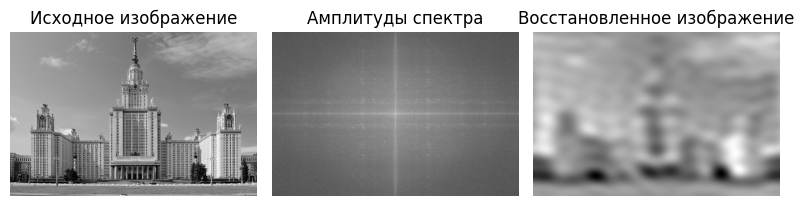

=======k = 20=======
Размерность исходного пространства = 1248528
Размерность нового пространства    = 1681


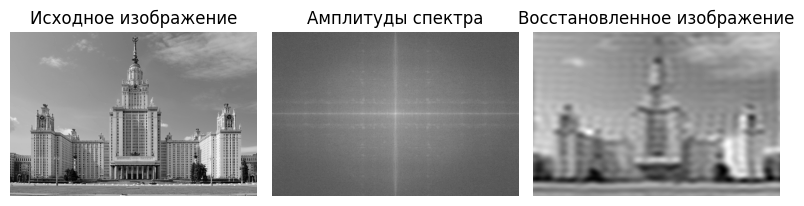

=======k = 50=======
Размерность исходного пространства = 1248528
Размерность нового пространства    = 10201


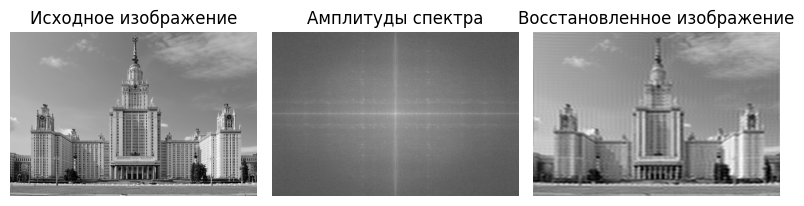

=======k = 100=======
Размерность исходного пространства = 1248528
Размерность нового пространства    = 40401


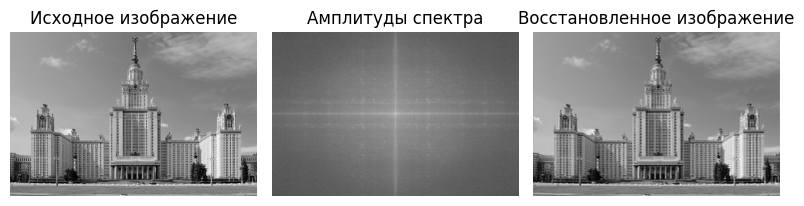

=======k = 120=======
Размерность исходного пространства = 1248528
Размерность нового пространства    = 58081


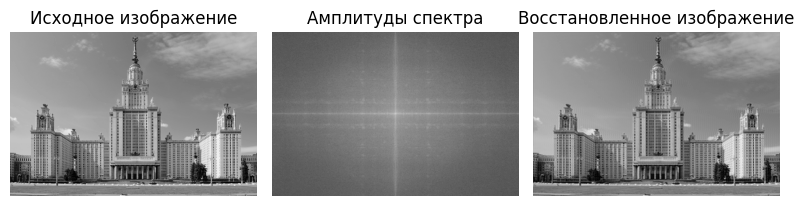

In [38]:
img = cv.imread('msu.jpg', cv.IMREAD_GRAYSCALE)

for k in [10, 20, 50, 100, 120]:
    print(f"=======k = {k}=======")
    _ = fft_transform(img, k, vis=True)

In [39]:
if not os.path.exists('diag.jpg'):
    !wget https://i.pinimg.com/736x/3f/35/f2/3f35f2051a296a05a62d2861196a667a.jpg
    !mv 3f35f2051a296a05a62d2861196a667a.jpg diag.jpg

=======k = 10=======
Размерность исходного пространства = 391876
Размерность нового пространства    = 441


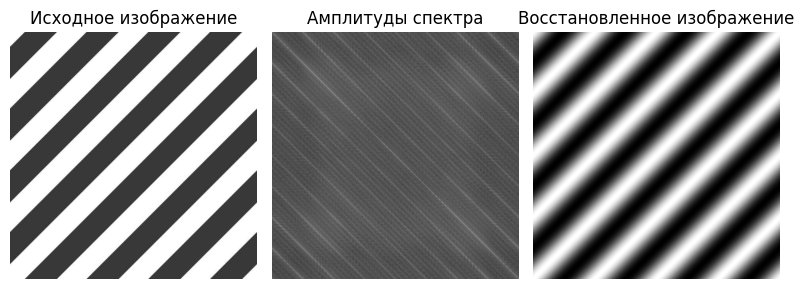

=======k = 20=======
Размерность исходного пространства = 391876
Размерность нового пространства    = 1681


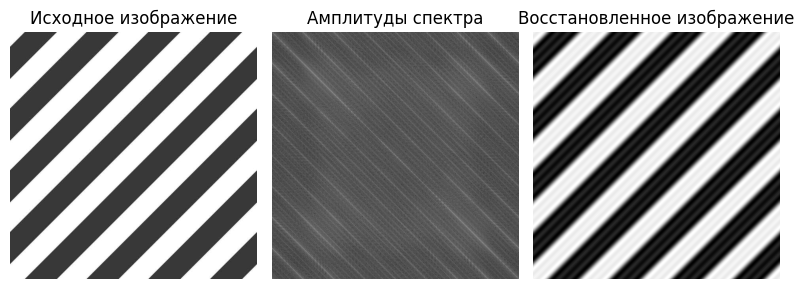

=======k = 50=======
Размерность исходного пространства = 391876
Размерность нового пространства    = 10201


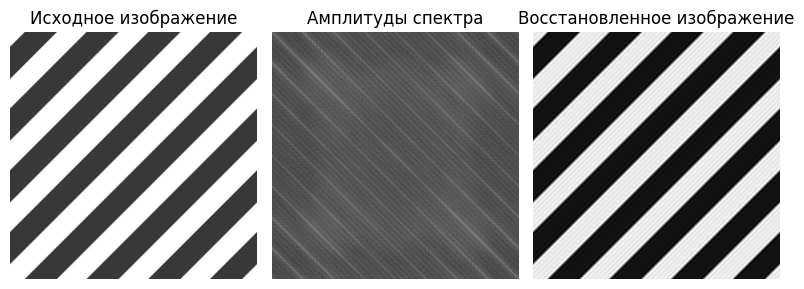

=======k = 100=======
Размерность исходного пространства = 391876
Размерность нового пространства    = 40401


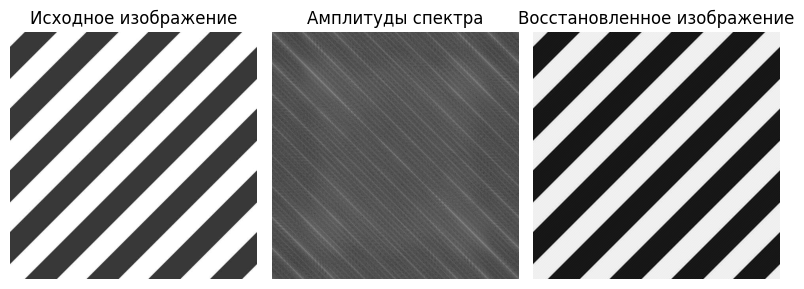

=======k = 120=======
Размерность исходного пространства = 391876
Размерность нового пространства    = 58081


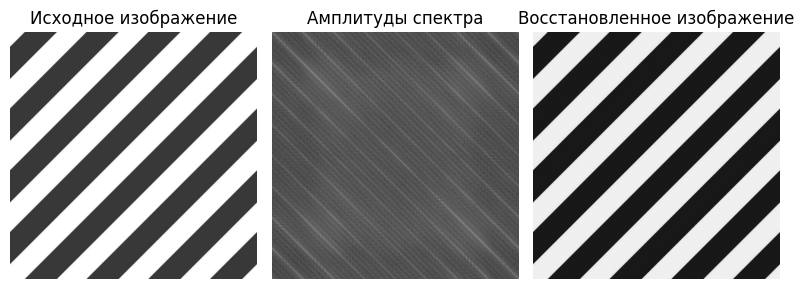

In [40]:
img = cv.imread('diag.jpg', cv.IMREAD_GRAYSCALE)

for k in [10, 20, 50, 100, 120]:
    print(f"=======k = {k}=======")
    _ = fft_transform(img, k, vis=True)

### Пример использования преобразования Фурье на датасете CIFAR-10

CIFAR-10 классический датасет для классификации изображений из 10 классов.

[Из чего состоит CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html).

In [41]:
from torchvision.datasets import CIFAR10
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from PIL import ImageOps
from functools import partial
import time

In [42]:
data_train = CIFAR10("./", train=True, download=True)
data_test = CIFAR10("./", train=False, download=True)

Files already downloaded and verified
Files already downloaded and verified


Подготовим данные.

In [43]:
def get_ml_dataset(data, transform=lambda x: x):
    X, y = [], []
    for i in range(len(data)):
        img, target = data[i]
        img_array = np.array(ImageOps.grayscale(img))
        img_array = transform(img_array)
        X.append(img_array)
        y.append(target)
    return np.array(X), np.array(y)

In [44]:
X_train, y_train = get_ml_dataset(data_train)
X_test, y_test = get_ml_dataset(data_test)
X_train.shape, X_test.shape

((50000, 32, 32), (10000, 32, 32))

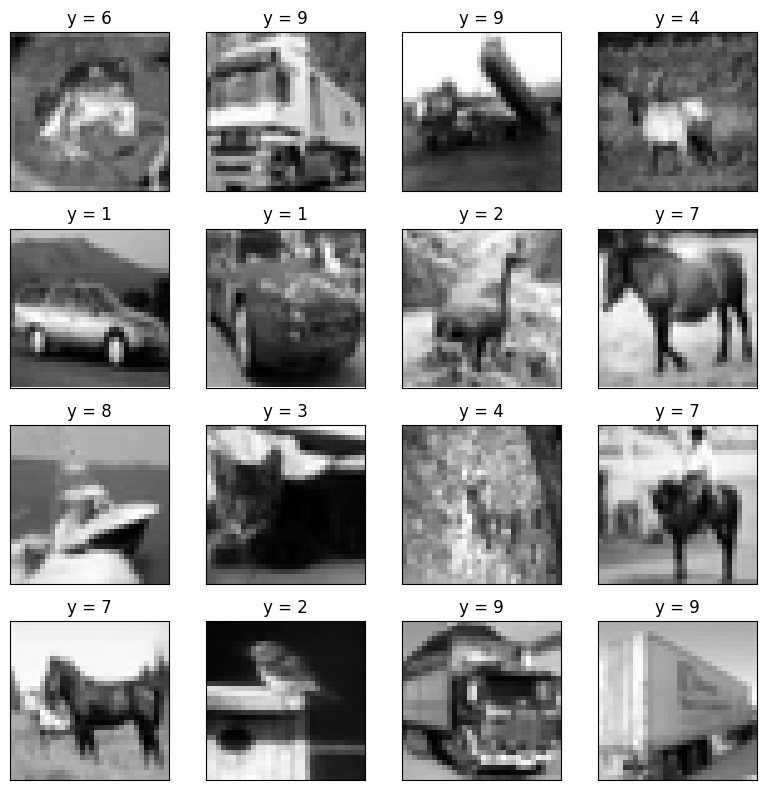

In [45]:
plt.figure(figsize=(8, 8))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"y = {y_train[i]}")
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()

In [46]:
%%time
clf = LogisticRegression()
clf.fit(X_train.reshape(X_train.shape[0], -1), y_train)

CPU times: user 1min 29s, sys: 1min 23s, total: 2min 53s
Wall time: 14.9 s


/home/alexandr/miniconda3/envs/ml/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [47]:
def calc_accuracy(X, y):
    y_pred = clf.predict(X.reshape(X.shape[0], -1))
    return accuracy_score(y_pred, y)

In [48]:
score_train = calc_accuracy(X_train, y_train)
score_test = calc_accuracy(X_test, y_test)

print(f"train score = {score_train:0.4f}")
print(f"test score  = {score_test:0.4f}")

train score = 0.3084
test score  = 0.2882


Качество выше случайного угадывания, а значит мы что-то полезное выучили.

===========k = 1===========
Размерность исходного пространства = 1024
Размерность нового пространства    = 9


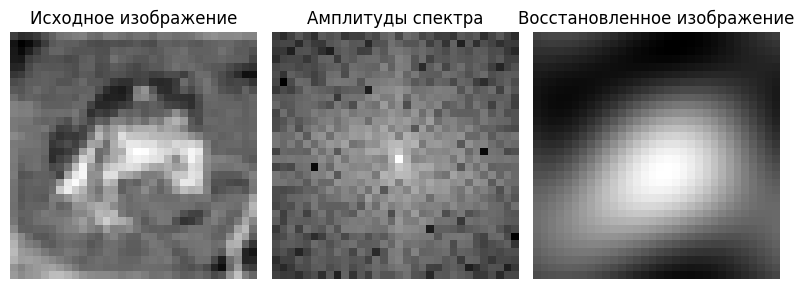

===========k = 5===========
Размерность исходного пространства = 1024
Размерность нового пространства    = 121


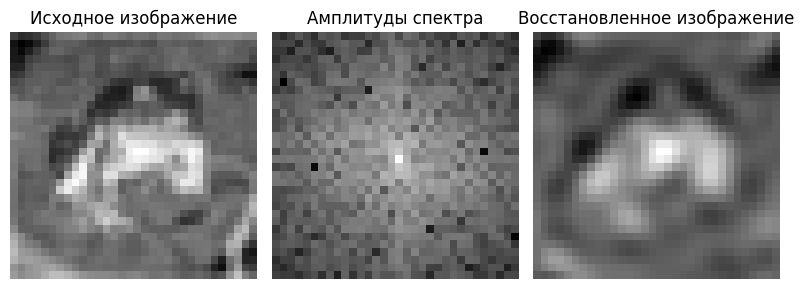

===========k = 10===========
Размерность исходного пространства = 1024
Размерность нового пространства    = 441


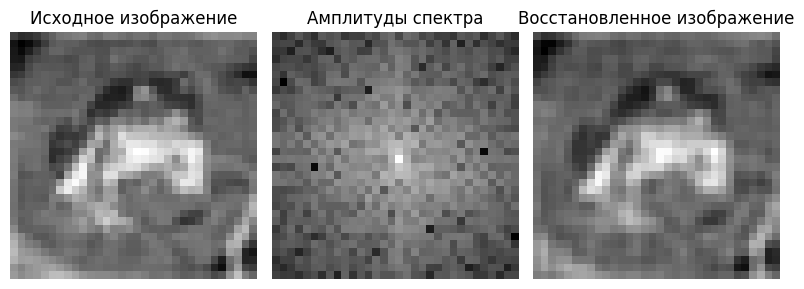

===========k = 14===========
Размерность исходного пространства = 1024
Размерность нового пространства    = 841


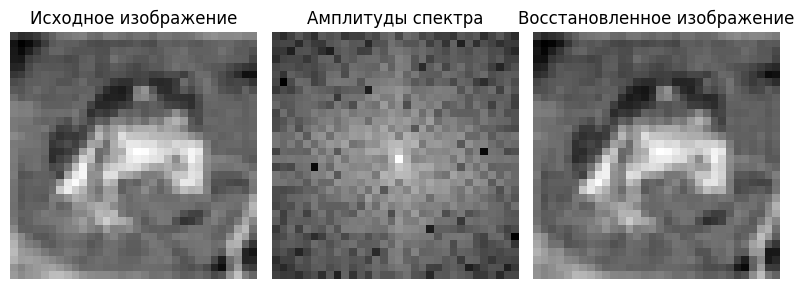

In [49]:
for k in [1, 5, 10, 14]:
    print(f"===========k = {k}===========")
    img = X_train[0]
    _ = fft_transform(img, k, vis=True)

In [50]:
for k in [1, 5, 10, 14]:
    fft_transform_k = partial(fft_transform, k=k)
    
    X_train, y_train = get_ml_dataset(data_train, fft_transform_k)
    X_test, y_test = get_ml_dataset(data_test, fft_transform_k)
    
    t_start = time.time()
    clf = LogisticRegression()
    clf.fit(X_train.reshape(X_train.shape[0], -1), y_train)
    t = time.time() - t_start
    
    score_train = calc_accuracy(X_train, y_train)
    score_test = calc_accuracy(X_test, y_test)
    
    print(f"===========k = {k}===========")
    print(f"Размерность признаков = {X_train.shape[1] * X_train.shape[2]}")
    print(f"Время обучения        = {t:0.4f}")
    print(f"train score           = {score_train:0.4f}")
    print(f"test score            = {score_test:0.4f}")

/tmp/ipykernel_13837/1304160526.py:9: RuntimeWarning: divide by zero encountered in log
  magnitude_spectrum = 20 * np.log(cv.magnitude(dft_shift[:,:,0], dft_shift[:,:,1]))
/home/alexandr/miniconda3/envs/ml/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/tmp/ipykernel_13837/1304160526.py:9: RuntimeWarning: divide by zero encountered in log
  magnitude_spectrum = 20 * np.log(cv.magnitude(dft_shift[:,:,0], dft_shift[:,:,1]))


===========k = 1===========
Размерность признаков = 9
Время обучения        = 2.2359
train score           = 0.1982
test score            = 0.1945


/home/alexandr/miniconda3/envs/ml/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/tmp/ipykernel_13837/1304160526.py:9: RuntimeWarning: divide by zero encountered in log
  magnitude_spectrum = 20 * np.log(cv.magnitude(dft_shift[:,:,0], dft_shift[:,:,1]))


===========k = 5===========
Размерность признаков = 121
Время обучения        = 3.3922
train score           = 0.3094
test score            = 0.3001


/home/alexandr/miniconda3/envs/ml/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/tmp/ipykernel_13837/1304160526.py:9: RuntimeWarning: divide by zero encountered in log
  magnitude_spectrum = 20 * np.log(cv.magnitude(dft_shift[:,:,0], dft_shift[:,:,1]))


===========k = 10===========
Размерность признаков = 441
Время обучения        = 5.0823
train score           = 0.3698
test score            = 0.3536
===========k = 14===========
Размерность признаков = 841
Время обучения        = 9.8144
train score           = 0.3909
test score            = 0.3609


/home/alexandr/miniconda3/envs/ml/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Мы почти без накладных расходов улучшили качество с 0.28 до 0.36 благодаря изменению признакового пространства. Работать с Фурье спектром бывает крайне полезно на практике.

## Пирамиды изображений

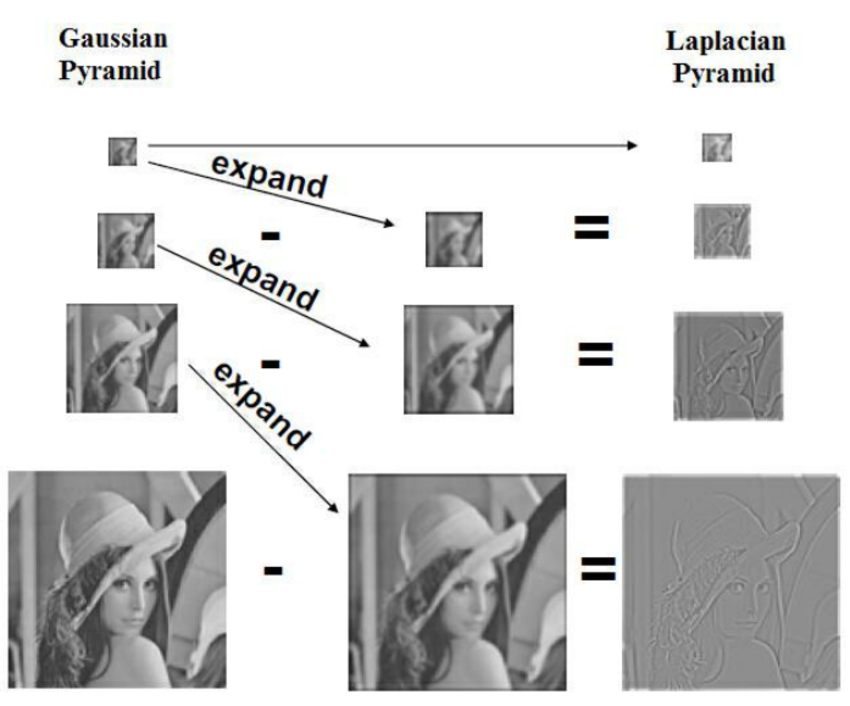

[Источник](https://www.researchgate.net/figure/a-Structure-of-Gaussian-Pyramid-b-Structure-of-Laplacian-Pyramid_fig13_275038450)

Рассмотрим пример из [OpenCV](https://docs.opencv.org/4.x/dc/dff/tutorial_py_pyramids.html).

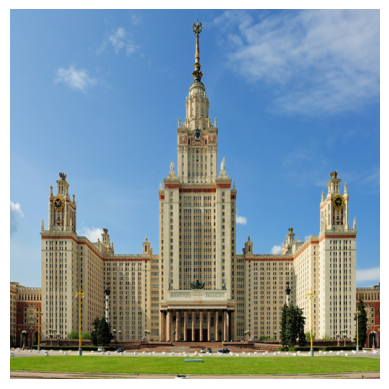

(512, 512, 3)

In [51]:
img = Image.open('msu.jpg').resize((512, 512))
img = np.array(img)

plt.imshow(img)
plt.axis('off')
plt.show()
img.shape

In [52]:
def build_gl_pyramid(img, N):
    G = img.copy()
    gpA = [G]
    for i in range(N):
        G = cv.pyrDown(G)
        gpA.append(G)

    lpA = [gpA[N - 1]]
    for i in range(N - 1, 0, -1):
        GE = cv.pyrUp(gpA[i])
        L = cv.subtract(gpA[i-1], GE)
        lpA.append(L)
    
    return gpA, lpA

def vis_gl_pyramid(gpA, lpA):
    fig, ax = plt.subplots(1, N, figsize=(14, 3))
    for i, G in enumerate(gpA[:-1]):
        ax[i].imshow(G)
        ax[i].set_title(fr"$2^{i}$", fontsize=14)
        ax[i].axis('off')
    fig.suptitle("Пирамида Гаусса", fontsize=16)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(1, N, figsize=(14, 3))
    for i, L in enumerate(lpA[::-1]):
        ax[i].imshow(L / np.max(L))
        ax[i].set_title(fr"$2^{i}$", fontsize=14)
        ax[i].axis('off')

    fig.suptitle("Пирамида Лапласа", fontsize=16)
    plt.tight_layout()
    plt.show()

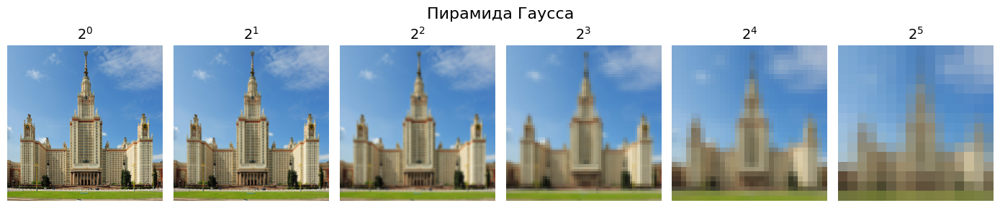

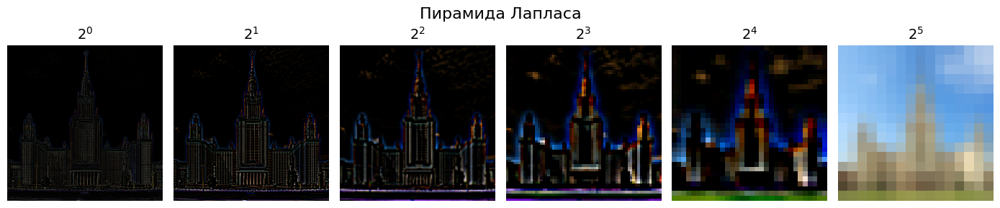

In [53]:
N = 6
gpA, lpA = build_gl_pyramid(img, N)

vis_gl_pyramid(gpA, lpA)

Идеи, которые, казалось бы, являются достаточно древними, находят свое применение в передовых методах. Как пример, текущий SOTA (на момент 2025 года) метод в авторегрессионной генерации изображений!

[Keyu Tian et al., 2024](https://arxiv.org/pdf/2404.02905), примерно 1200 цитирований.

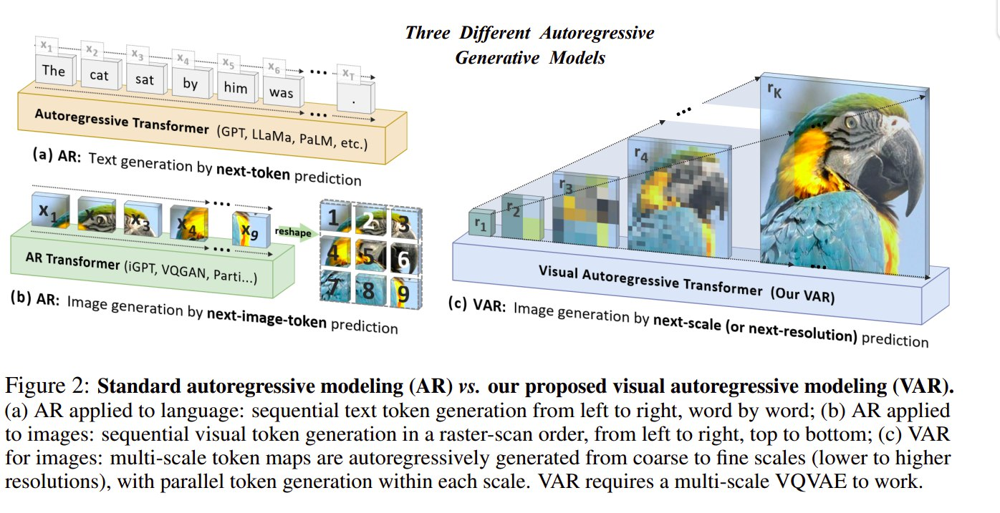

Во многом актуальность этих техник связана с тем, что пирамиды связаны с частотами, подробнее можно почитать в [Foundations of Computer Vision от MIT](https://visionbook.mit.edu/pyramids_new_notation.html).

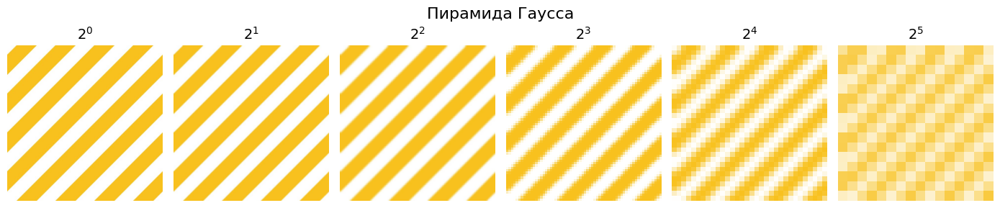

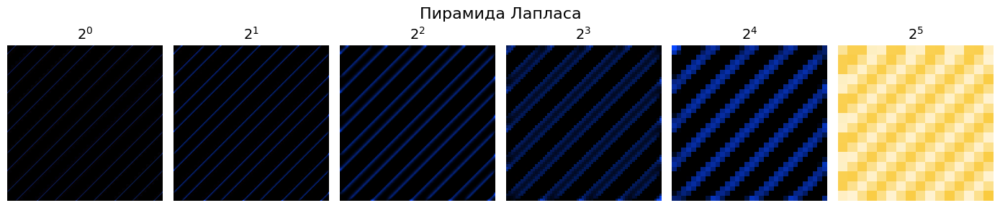

In [54]:
img = Image.open('diag.jpg').resize((512, 512))
img = np.array(img)

gpA, lpA = build_gl_pyramid(img, N)
vis_gl_pyramid(gpA, lpA)

Кроме того, мы можем благодаря пирамидам смещивать изображения.

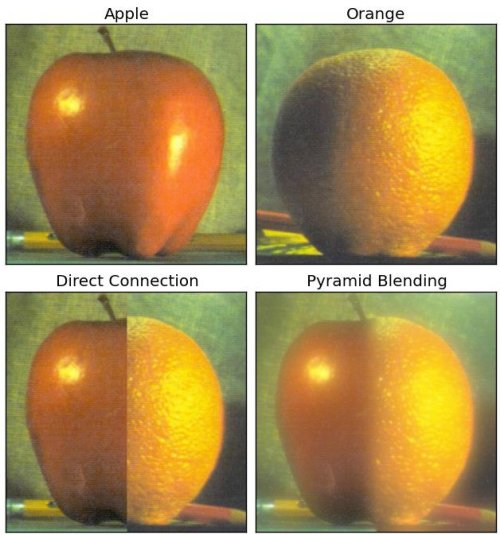

Посмотрим пример из [OpenCV](https://docs.opencv.org/4.x/dc/dff/tutorial_py_pyramids.html) на наших данных. Подробнее о методе и его использование на практике можно посмотреть [в этом видео](https://youtu.be/U7qa7i0K9C4?si=bLWwHAALaQVCTuwY). Пример ниже упрощенная версия примера из [Foundations of Computer Vision от MIT](https://visionbook.mit.edu/pyramids_new_notation.html).

In [55]:
if not os.path.exists("orange.jpg"):
    !wget https://visionbook.mit.edu/figures/pyramids/orange.jpg

if not os.path.exists("apple.jpg"):
    !wget https://visionbook.mit.edu/figures/pyramids/apple.jpg

In [56]:
imgA = Image.open('apple.jpg').resize((512, 512))
imgA = np.array(imgA)
imgB = Image.open('orange.jpg').resize((512, 512))
imgB = np.array(imgB)

In [57]:
results = {}
N_grid = [1, 2, 3, 4, 5, 6]
for N in N_grid:
    gpA, lpA = build_gl_pyramid(imgA, N)
    gpB, lpB = build_gl_pyramid(imgB, N)


    LS = []
    for la,lb in zip(lpA,lpB):
        rows, cols, dpt = la.shape

        ls = np.hstack((la[:, :cols // 2], lb[:, cols // 2:]))
        LS.append(ls)

    ls_ = LS[0]
    for i in range(1, N):
        ls_ = cv.pyrUp(ls_)
        ls_ = cv.add(ls_, LS[i])
    
    results[N] = ls_

Обратите внимание, что $N = 1$ смещивает на уровне пикселей, проверим это.

In [58]:
assert (results[1] == np.hstack((imgA[:, :256], imgB[:, 256:]))).all()

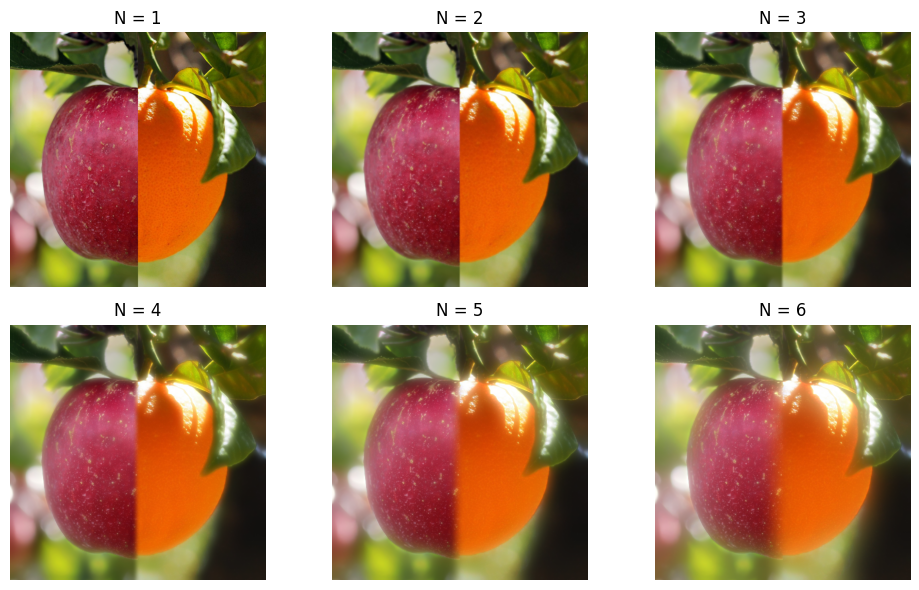

In [59]:
fig, ax = plt.subplots(2, 3, figsize=(10, 6), sharex=True, sharey=True)
ax = ax.ravel()

for idx, (k, v) in enumerate(results.items()):
    
    ax[idx].set_title(f"N = {k}")
    ax[idx].imshow(v)
    ax[idx].axis('off')
plt.tight_layout()
plt.show()

Как видно из демонстрации, чем больше $N$, тем больше смещивание двух изображений.

## Примеры использования обработки изображений


*   Предобработка входных изображений (Удаление шума, преобразование цветов)
*   Постобработка изображений (Удаление шумовых объектов, отверстий)
*   Выделение дополнительных признаков (Выделение важных объектов, областей)
*   Аугментация объектов (Преобразование объектов в ходе обучения/применения
модели)

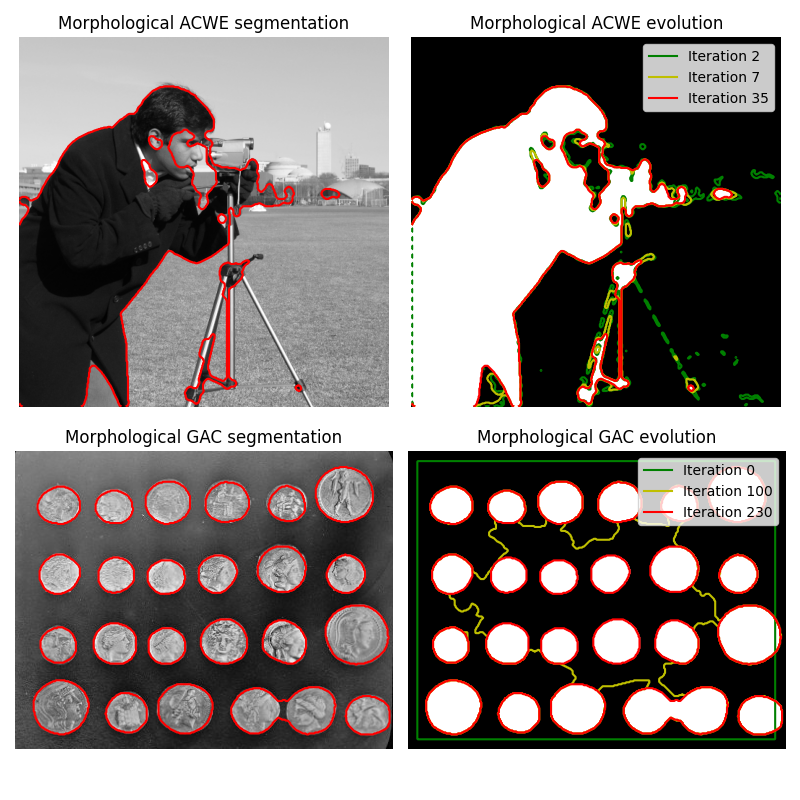

[Источник](https://scikit-image.org/docs/0.20.x/auto_examples/segmentation/plot_morphsnakes.html)

Хороший пример использования трансформаций: датасет MNIST.

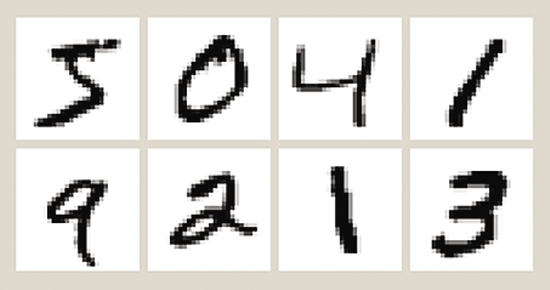

Класс изображения не меняется при:


* сдвигах на 1-10 пикселей;
* поворотах на 10-15 градусов в каждую из сторон;
* размытии, удалении шумов.

Добавив преобразованные объекты в исходную выборку, можно существенно повысить качество.

Часто используемые методы аугментации:

* отражение
* сдвиг
* поворот
* масштабирование (увеличение)
* добавление шума, размытие
* изменение яркости, контрастности, цветовой гаммы
* удаление части изображения

## Спасибо за внимание!